In [1]:
from GeoEntityModel import GeoEntityModel
import torch, math
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from GeoUtils import collator, GeoDataset
from torch.utils.data import DataLoader
from globals import ID2LABEL_GEONER, LABEL2ID_GEONER

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
cleandata_path = "D:\\GeoTKG\\cleandata\\geo\\"
train = GeoDataset(cleandata_path + "train.json")
eval = GeoDataset(cleandata_path + "eval.json")
train_loader = DataLoader(train, batch_size=8, shuffle=True, collate_fn=collator)
eval_loader = DataLoader(eval, batch_size=8, shuffle=False, collate_fn=collator)

In [3]:
NUM_EPOCHS = 15
ENC_LR = 5e-5
NONENC_LR = 1e-3
WARMUP_EPOCHS = 5
EVALUATION_EPOCHS = 5
BASE_ENC_MODEL = "roberta-base"
WEIGHT_DECAY = 0.01

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = GeoEntityModel(base=BASE_ENC_MODEL).to(device)
for p in model.enc.parameters(): p.requires_grad = False

optimizer = AdamW([
        {"params": [p for n,p in model.named_parameters() if n.startswith("enc.")], "lr": ENC_LR},
        {"params": [p for n,p in model.named_parameters() if not n.startswith("enc.")], "lr": NONENC_LR},
    ], weight_decay=0.01)

steps_per_epoch = len(train_loader)
num_train_steps = steps_per_epoch * NUM_EPOCHS
num_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_train_steps)

scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

def make_optim(unfrozen: bool):
    groups = []
    if unfrozen:
        groups.append({"params": model.enc.parameters(), "lr": ENC_LR})
    else:
        # keep enc group empty or skip entirely; either is fine
        pass
    nonenc = [p for n, p in model.named_parameters() if not n.startswith("enc.")]
    groups.append({"params": nonenc, "lr": NONENC_LR})
    return AdamW(groups, weight_decay=WEIGHT_DECAY)

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.dense.bias', 'lm_head.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
global_step = 0
history = {"loss": [], "f1": [], "eval_loss":[], "lr": []}
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        ctx = (torch.autocast(device_type='cuda', dtype=torch.float16))
        with ctx:
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["ner_labels"],
            )
            loss = out["loss"]

        scaler.scale(loss).backward()

        # Unscale before clipping, then clip
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Optimizer step guarded by scaler
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        # Step scheduler ONLY if optimizer actually stepped (no inf/NaN)
        if scaler.get_scale() >= scale_before:
            sched.step()

        epoch_loss += loss.item()
        global_step += 1
        
    # ---- unfreeze after warmup epochs ----
    if epoch + 1 == WARMUP_EPOCHS:
        for p in model.enc.parameters():
            p.requires_grad = True
        # rebuild optimizer & scheduler for the remaining steps
        optimizer = make_optim(unfrozen=True)
        remaining_steps = steps_per_epoch * (NUM_EPOCHS - (epoch + 1))
        warmup_rem = 0 
        sched = get_cosine_schedule_with_warmup(optimizer, warmup_rem, remaining_steps)

    # ---- validation ----
    if (epoch + 1) % EVALUATION_EPOCHS == 0:
        model.eval()
        with torch.no_grad():
            batch_evaluation = model.evaluate_dataloader(eval_loader)
        history["f1"].append(batch_evaluation["f1"])
        history["eval_loss"].append(batch_evaluation["eval_loss"])
        history["loss"].append(epoch_loss/steps_per_epoch)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"EPOCH{epoch+1}: F1={batch_evaluation['f1']:.4f}, Train Loss={epoch_loss/steps_per_epoch:.4f}, Eval Loss={batch_evaluation['eval_loss']:.4f}")

              precision    recall  f1-score   support

    LOCATION     0.4132    0.3549    0.3818      1006
     MINERAL     0.6736    0.8071    0.7343      1327
 ORE_DEPOSIT     0.6323    0.4804    0.5460       383
        ROCK     0.5173    0.5913    0.5519      1894
       STRAT     0.1839    0.1246    0.1486       642
   TIMESCALE     0.9067    0.9714    0.9379       210

   micro avg     0.5415    0.5522    0.5468      5462
   macro avg     0.5545    0.5550    0.5501      5462
weighted avg     0.5200    0.5522    0.5319      5462

EPOCH5: F1=0.5468, Train Loss=0.1690, Eval Loss=0.2472
              precision    recall  f1-score   support

    LOCATION     0.5607    0.6153    0.5867      1006
     MINERAL     0.8138    0.9186    0.8630      1327
 ORE_DEPOSIT     0.8692    0.7285    0.7926       383
        ROCK     0.7845    0.7994    0.7918      1894
       STRAT     0.8564    0.7430    0.7957       642
   TIMESCALE     0.9507    0.9190    0.9346       210

   micro avg     0.766

In [7]:
model.save("results/geo_model/geo_model.pt")

In [8]:
import json
with open("results/geo_model/history.json", "w") as f:
    json.dump(history, f, indent=2)

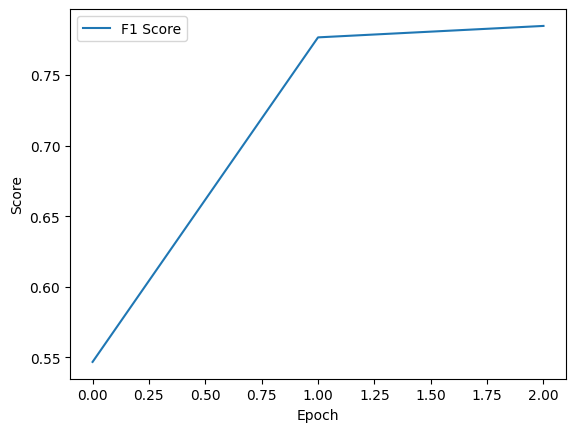

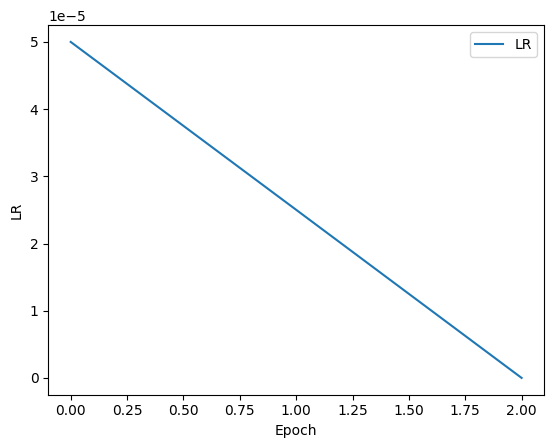

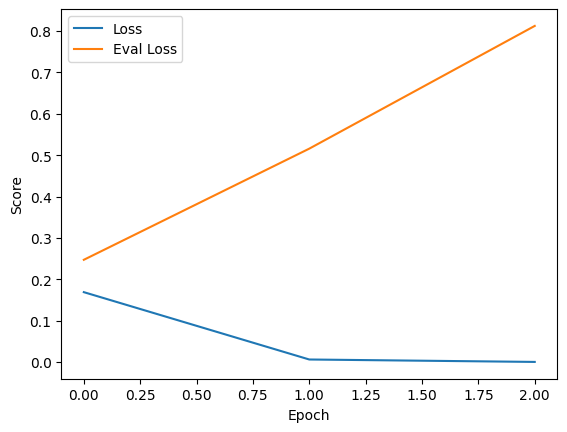

In [9]:
import matplotlib.pyplot as plt

plt.plot(history["f1"], label="F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.plot(history["lr"], label="LR")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.legend()
plt.show()

plt.plot(history["loss"], label="Loss")
plt.plot(history["eval_loss"], label="Eval Loss")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()